# LSTM — Weekend Gap Prediction

**Role in the project:** Sequential model for temporal pattern detection. Logistic regression and XGBoost treat each Monday row as an independent observation — they cannot see whether RSI has been rising for three consecutive weeks, or whether volume has been building. LSTM (Long Short-Term Memory) is designed specifically to learn from sequences: it processes 4 consecutive weekly observations per ticker and decides what information to carry forward and what to forget.

**Key differences from LogReg and XGBoost:**
- **Input:** sequences of 4 weeks, not single rows
- **Temporal structure:** the model can learn that momentum over N weeks predicts the gap direction
- **Rolling 3-year training window:** only the 3 most recent years before the test year are used for training. Discards stale market regimes and prevents older data from poisoning later folds.
- **No fundamentals:** quarterly metrics repeat across 13 consecutive weekly rows — the LSTM gate mechanism has nothing temporal to learn from a flat dimension
- **Preprocessing required:** LSTM gates use sigmoid/tanh activations, sensitive to feature scale

**Configuration chosen via systematic experiment:** 6 variants were tested across window size (4 vs 8 weeks) and training strategy (expanding vs rolling 3yr/4yr). Short window + rolling 3yr achieved the best average AUC (0.5614) across non-COVID folds.

**The research question LSTM answers:** Is there sequential, week-over-week signal in technical features that static models cannot detect?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score,
                             confusion_matrix, roc_curve)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')

PyTorch 2.8.0  |  device: cpu


## 1. Load Data & Define Feature Set

In [2]:
df_all  = pd.read_csv('../structured_csv_data_files/fetched_data/dataset_clean.csv',
                      parse_dates=['Date'])

primary = df_all[df_all['is_extreme_event'] == 0].copy().reset_index(drop=True)
extreme = df_all[df_all['is_extreme_event'] == 1].copy().reset_index(drop=True)

gap_primary = primary['GapUp'].mean()
gap_extreme = extreme['GapUp'].mean()
print(f'Primary dataset: {len(primary):,} rows   GapUp rate: {gap_primary:.3f}')
print(f'Extreme events:  {len(extreme):,} rows   GapUp rate: {gap_extreme:.3f}')

Primary dataset: 8,146 rows   GapUp rate: 0.516
Extreme events:  291 rows   GapUp rate: 0.450


In [3]:
# LSTM uses 14 technical features — fundamentals are excluded.
#
# Why no fundamentals:
#   GrossMargin, NetMargin, RoA, RevGrowthQoQ are reported quarterly.
#   In the dataset, each fundamental value is repeated across ~13 consecutive
#   weekly rows within the same quarter. Feeding a flat dimension (same value
#   for 8 consecutive timesteps) gives the LSTM gate mechanism nothing temporal
#   to learn. The LSTM would be forced to treat it as a static bias — which is
#   exactly what LogReg and XGBoost already do, with no benefit from sequencing.
#
# Missingness indicators excluded: encode data quality, not market dynamics.
# 4 leaky price aggregates still excluded (same as all models).

MOMENTUM   = ['RSI', 'MACD', 'ROC', 'StochPercK']
TREND      = ['CloseVEma50', 'CloseVSma20', 'ADX']
VOLATILITY = ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
VOLUME     = ['OBV', 'MFI', 'VolumeRatio']
PRICE_AGG  = ['WeeklyRange']

FEATURES = MOMENTUM + TREND + VOLATILITY + VOLUME + PRICE_AGG
TARGET   = 'GapUp'
WINDOW   = 4   # 4-week lookback window (chosen via variant experiment)

print(f'Feature count:    {len(FEATURES)}')
print(f'Sequence window:  {WINDOW} weeks')
for grp, feats in [('Momentum', MOMENTUM), ('Trend', TREND), ('Volatility', VOLATILITY),
                   ('Volume', VOLUME), ('Price Agg', PRICE_AGG)]:
    print(f'  {grp:12s}: {feats}')

missing = [f for f in FEATURES if f not in primary.columns]
print(f'\nMissing columns: {missing if missing else "None — all 14 present"}')

Feature count:    14
Sequence window:  4 weeks
  Momentum    : ['RSI', 'MACD', 'ROC', 'StochPercK']
  Trend       : ['CloseVEma50', 'CloseVSma20', 'ADX']
  Volatility  : ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
  Volume      : ['OBV', 'MFI', 'VolumeRatio']
  Price Agg   : ['WeeklyRange']

Missing columns: None — all 14 present


## 2. Preprocessing — Required for LSTM

Unlike XGBoost, LSTM is sensitive to feature scale. The LSTM cell uses sigmoid and tanh activation functions internally — large input values saturate these functions, killing gradient flow during backpropagation (the vanishing gradient problem at the input level).

**Approach:** `StandardScaler` fitted on the training window only, applied to validation and test. The scaler is fitted on all training timesteps (not just the first row of each sequence) to capture the full distribution of each feature.

**OBV note:** OBV is cumulative and not cross-ticker comparable. StandardScaler within each fold's training data effectively z-scores it; the per-ticker OBV range will vary but the scaler captures the aggregate training distribution. This is sufficient since sequences are per-ticker and the model sees relative OBV dynamics within each sequence.

## 3. Sequence Construction — 4-Week Sliding Window

Each sequence pairs 4 consecutive weekly rows (the input) with the GapUp label of the 4th (most recent) row as the target. Sequences are built per-ticker to prevent cross-ticker contamination.

A 4-week window was selected over 8 weeks through systematic comparison: shorter windows generalise better across market regimes because they focus on near-term momentum rather than medium-term patterns that may not repeat in a different year.

The target week's year determines which fold split a sequence belongs to — this ensures temporal integrity across the walk-forward folds.

In [4]:
def build_sequences(df, features, target, window=8):
    """
    Builds per-ticker sliding window sequences.

    For each ticker, iterates chronologically. Each sequence of length `window`
    uses rows [i-window+1 .. i] as input and the label of row i as target.
    The year of row i (the target week) determines fold membership.

    Returns
    -------
    X       : (N, window, n_features)  float32
    y       : (N,)                     float32 binary label
    years   : (N,)                     int     year of target week
    extreme : (N,)                     int     1 if target row is extreme event
    """
    X_list, y_list, yr_list, ex_list = [], [], [], []
    has_extreme = 'is_extreme_event' in df.columns

    for ticker, grp in df.sort_values(['Ticker', 'Date']).groupby('Ticker'):
        grp        = grp.reset_index(drop=True)
        feat_vals  = grp[features].values.astype(np.float32)
        tgt_vals   = grp[target].values.astype(np.float32)
        yr_vals    = grp['Year'].values
        ex_vals    = grp['is_extreme_event'].values if has_extreme else np.zeros(len(grp), dtype=int)

        for i in range(window - 1, len(grp)):
            X_list.append(feat_vals[i - window + 1 : i + 1])
            y_list.append(tgt_vals[i])
            yr_list.append(yr_vals[i])
            ex_list.append(ex_vals[i])

    return (np.array(X_list, dtype=np.float32),
            np.array(y_list,  dtype=np.float32),
            np.array(yr_list),
            np.array(ex_list))


# Build sequences once from primary (non-COVID) rows.
# Filter by target year during fold construction.
X_all, y_all, years_all, _ = build_sequences(primary, FEATURES, TARGET, WINDOW)

print(f'Total sequences:  {len(X_all):,}')
print(f'Sequence shape:   {X_all.shape}  (N, window, features)')
gap_rate = y_all.mean()
print(f'GapUp rate:       {gap_rate:.3f}')
print()
print('Sequences per year:')
for yr in sorted(np.unique(years_all)):
    n = (years_all == yr).sum()
    print(f'  {yr}: {n:,}')

Total sequences:  8,071
Sequence shape:   (8071, 4, 14)  (N, window, features)
GapUp rate:       0.517

Sequences per year:
  2016: 662
  2017: 979
  2018: 966
  2019: 992
  2020: 613
  2021: 917
  2022: 997
  2023: 953
  2024: 992


## 4. LSTM Architecture

A single-layer LSTM with a linear output head.

| Component | Detail | Rationale |
|-----------|--------|-----------|
| LSTM layer | 1 layer, hidden_size tuned | Single layer avoids vanishing gradients with small datasets (~3k–7k sequences) |
| Last timestep | `out[:, -1, :]` | The final hidden state encodes all sequence history via the LSTM's memory |
| Dropout | After LSTM, before linear | Regularization; prevents overfitting to training sequences |
| Linear + Sigmoid | Maps hidden → [0,1] | Probability of GapUp |
| Loss | BCELoss | Standard for binary classification |
| Optimizer | Adam (lr=0.001) | Adaptive learning rate, robust default for LSTM |

In [5]:
class LSTMGapPredictor(nn.Module):
    """
    Single-layer LSTM for binary weekend gap prediction.
    Input:  (batch, seq_len=8, input_size=14)
    Output: (batch,) — sigmoid probability of GapUp
    """
    def __init__(self, input_size, hidden_size, dropout=0.2):
        super().__init__()
        self.lstm    = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                               num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq_len, hidden)
        out    = out[:, -1, :]         # last timestep: (batch, hidden)
        out    = self.dropout(out)
        return torch.sigmoid(self.fc(out)).squeeze(-1)  # (batch,)

In [6]:
def make_loader(X, y, batch_size=64, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def evaluate(model, X, y):
    """Return (auc, accuracy, predicted_probabilities)."""
    model.eval()
    with torch.no_grad():
        proba = model(torch.tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    preds = (proba >= 0.5).astype(int)
    return roc_auc_score(y, proba), accuracy_score(y, preds), proba


def fit_model(X_train, y_train, X_val, y_val,
              hidden_size, dropout, lr=0.001,
              max_epochs=50, patience=10, batch_size=64):
    """
    Trains the LSTM with early stopping on val AUC.
    Returns the best model and the best val AUC achieved.
    """
    model     = LSTMGapPredictor(X_train.shape[2], hidden_size, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    loader    = make_loader(X_train, y_train, batch_size=batch_size)

    best_auc, best_state, wait = -np.inf, None, 0

    for _ in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        val_auc, _, _ = evaluate(model, X_val, y_val)
        if val_auc > best_auc + 1e-4:
            best_auc   = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait       = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_auc

## 5. Walk-Forward Validation & Hyperparameter Tuning

**Rolling 3-year training window** — only the 3 most recent years before the test year are used for training, rather than all available history (expanding window). This prevents older market regimes (e.g., 2016–2018 pre-AI-era dynamics) from dominating the training set in later folds.

| Test year | Training years | Rationale |
|-----------|---------------|-----------|
| 2019 | 2016–2018 | Same as expanding (only 3 years available) |
| 2020 | 2017–2019 | Drops 2016 |
| 2021 | 2018–2020 | Drops 2016–2017 |
| 2022 | 2019–2021 | Drops 2016–2018 |
| 2023 | 2020–2022 | Drops 2016–2019 |
| 2024 | 2021–2023 | Drops 2016–2020 |

**LSTM hyperparameters tuned:**

| Parameter | What it controls | Grid |
|-----------|-----------------|------|
| `hidden_size` | Capacity of the LSTM memory. | 32, 64 |
| `dropout` | Fraction of hidden units zeroed after LSTM output. | 0.2, 0.3 |

Learning rate fixed at 0.001. Number of layers fixed at 1.

**Inner validation:** last calendar year of each training window is carved off for hyperparameter selection. Best configuration is then refit on the full 3-year training window.

In [7]:
FOLDS = [
    {'train_years': [2016, 2017, 2018], 'test_year': 2019},
    {'train_years': [2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2021, 2022, 2023], 'test_year': 2024},
]

PARAM_GRID = [
    {'hidden_size': h, 'dropout': d}
    for h in [32, 64]
    for d in [0.2, 0.3]
]

print(f'Training strategy: rolling 3-year window')
print(f'Hyperparameter combinations: {len(PARAM_GRID)}')
print()
for fold in FOLDS:
    n_train = np.isin(years_all, fold['train_years']).sum()
    n_test  = (years_all == fold['test_year']).sum()
    yr_range = f"{fold['train_years'][0]}-{fold['train_years'][-1]}"
    print(f"  Train {yr_range} ({n_train:,} seqs) → Test {fold['test_year']} ({n_test:,} seqs)")

Training strategy: rolling 3-year window
Hyperparameter combinations: 4

  Train 2016-2018 (2,607 seqs) → Test 2019 (992 seqs)
  Train 2017-2019 (2,937 seqs) → Test 2020 (613 seqs)
  Train 2018-2020 (2,571 seqs) → Test 2021 (917 seqs)
  Train 2019-2021 (2,522 seqs) → Test 2022 (997 seqs)
  Train 2020-2022 (2,527 seqs) → Test 2023 (953 seqs)
  Train 2021-2023 (2,867 seqs) → Test 2024 (992 seqs)


In [8]:
# Walk-forward loop.
# For each fold:
#   1. Split sequences by target year.
#   2. Fit StandardScaler on full training sequences (all timesteps flattened).
#   3. Grid search (4 combos) using inner train/val split.
#   4. Refit best config on full training window with early stopping.
#   5. Evaluate on test year.
#   6. Compute permutation importance (5 shuffles per feature).

fold_results     = []
fold_best_params = []
fold_proba       = []
fold_y_test      = []
fold_importances = []

scaler = StandardScaler()

for fold in FOLDS:
    test_year     = fold['test_year']
    train_years   = fold['train_years']
    inner_val_yr  = max(train_years)
    inner_trn_yrs = [y for y in train_years if y != inner_val_yr]

    mask_itrn = np.isin(years_all, inner_trn_yrs)
    mask_ival  = (years_all == inner_val_yr)
    mask_full  = np.isin(years_all, train_years)
    mask_test  = (years_all == test_year)

    X_itrn, y_itrn = X_all[mask_itrn], y_all[mask_itrn]
    X_ival,  y_ival  = X_all[mask_ival],  y_all[mask_ival]
    X_full,  y_full  = X_all[mask_full],  y_all[mask_full]
    X_test,  y_test  = X_all[mask_test],  y_all[mask_test]

    # Fit scaler on full training sequences (all timesteps)
    n_feat = X_full.shape[2]
    scaler.fit(X_full.reshape(-1, n_feat))

    def sc(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape).astype(np.float32)

    Xi_s = sc(X_itrn); Xv_s = sc(X_ival)
    Xf_s = sc(X_full); Xt_s = sc(X_test)

    # Hyperparameter search on inner split
    best_val_auc, best_params = -np.inf, None
    for params in PARAM_GRID:
        torch.manual_seed(42)
        _, val_auc = fit_model(Xi_s, y_itrn, Xv_s, y_ival, **params)
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_params  = params.copy()

    # Refit best config on full training window
    torch.manual_seed(42)
    best_model, _ = fit_model(Xf_s, y_full, Xv_s, y_ival, **best_params)

    # Evaluate on test year
    auc, acc, proba = evaluate(best_model, Xt_s, y_test)
    preds    = (proba >= 0.5).astype(int)
    baseline = max(y_test.mean(), 1 - y_test.mean())

    fold_results.append({
        'Test year':  test_year,
        'Accuracy':   round(acc, 4),
        'Precision':  round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall':     round(recall_score(y_test, preds, zero_division=0), 4),
        'F1':         round(f1_score(y_test, preds, zero_division=0), 4),
        'AUC-ROC':    round(auc, 4),
        'Baseline':   round(baseline, 4),
        'hidden_size': best_params['hidden_size'],
        'dropout':     best_params['dropout'],
    })
    fold_best_params.append(best_params)
    fold_proba.append(proba)
    fold_y_test.append(y_test)

    # Permutation importance: shuffle each feature independently across sequences,
    # measure average AUC drop. Positive drop = feature contributes.
    perm_imp = {}
    for fi, feat in enumerate(FEATURES):
        drops = []
        for _ in range(5):
            Xp = Xt_s.copy()
            Xp[:, :, fi] = Xp[np.random.permutation(Xp.shape[0]), :, fi]
            p_auc, _, _ = evaluate(best_model, Xp, y_test)
            drops.append(p_auc)
        perm_imp[feat] = round(auc - np.mean(drops), 5)
    fold_importances.append(perm_imp)

    h = best_params['hidden_size']; dr = best_params['dropout']
    print(f'Fold test={test_year} | hidden={h} dropout={dr} | '
          f'Acc={acc:.3f} AUC={auc:.3f} Baseline={baseline:.3f}')

Fold test=2019 | hidden=32 dropout=0.2 | Acc=0.552 AUC=0.565 Baseline=0.526


Fold test=2020 | hidden=64 dropout=0.2 | Acc=0.556 AUC=0.561 Baseline=0.564


Fold test=2021 | hidden=64 dropout=0.3 | Acc=0.538 AUC=0.548 Baseline=0.514


Fold test=2022 | hidden=32 dropout=0.2 | Acc=0.520 AUC=0.575 Baseline=0.588


Fold test=2023 | hidden=32 dropout=0.3 | Acc=0.547 AUC=0.554 Baseline=0.511


Fold test=2024 | hidden=64 dropout=0.2 | Acc=0.506 AUC=0.544 Baseline=0.573


## 6. Walk-Forward Results

In [9]:
# Results table — same format as LogReg and XGBoost for direct comparison.
# COVID fold (2020) highlighted; excluded from primary averages.

results_df = pd.DataFrame(fold_results).set_index('Test year')

display(results_df.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1': '{:.4f}', 'AUC-ROC': '{:.4f}', 'Baseline': '{:.4f}'})
    .highlight_between(subset=pd.IndexSlice[[2020], :], color='#fff3cd'))

non_covid = results_df[results_df.index != 2020]
print(f'\nAverage metrics (excluding COVID fold):')
print(f'  Accuracy:  {non_covid["Accuracy"].mean():.4f}')
print(f'  Precision: {non_covid["Precision"].mean():.4f}')
print(f'  Recall:    {non_covid["Recall"].mean():.4f}')
print(f'  F1:        {non_covid["F1"].mean():.4f}')
print(f'  AUC-ROC:   {non_covid["AUC-ROC"].mean():.4f}')
print(f'  Baseline:  {non_covid["Baseline"].mean():.4f}')

,Accuracy,Precision,Recall,F1,AUC-ROC,Baseline,hidden_size,dropout
Test year,,,,,,,,
2019,0.5524,0.5670,0.6322,0.5978,0.5647,0.5262,32,0.200000
2020,0.5563,0.6341,0.5058,0.5627,0.5614,0.5644,64,0.200000
2021,0.5376,0.5456,0.5966,0.5700,0.5484,0.5136,64,0.300000
2022,0.5196,0.4500,0.7445,0.5610,0.5751,0.5878,32,0.200000
2023,0.5467,0.5326,0.5966,0.5628,0.5540,0.5110,32,0.300000
2024,0.5060,0.5907,0.4472,0.5090,0.5443,0.5726,64,0.200000



Average metrics (excluding COVID fold):
  Accuracy:  0.5325
  Precision: 0.5372
  Recall:    0.6034
  F1:        0.5601
  AUC-ROC:   0.5573
  Baseline:  0.5422


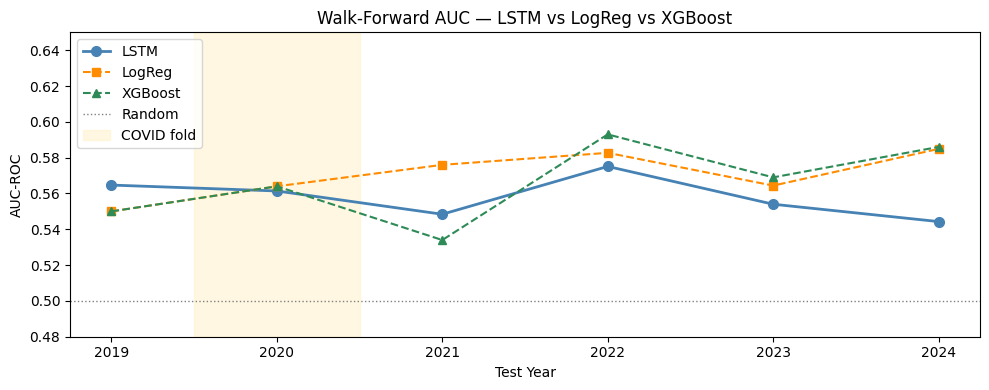

In [10]:
# AUC evolution over folds with LogReg and XGBoost overlaid.
# Shows whether LSTM improves on static models in any particular year.

logreg_aucs = {2019: 0.5500, 2020: 0.5640, 2021: 0.5760, 2022: 0.5827, 2023: 0.5644, 2024: 0.5849}
xgb_aucs    = {2019: 0.5500, 2020: 0.5640, 2021: 0.5340, 2022: 0.5930, 2023: 0.5690, 2024: 0.5860}

test_years = results_df.index.tolist()
lstm_auc   = results_df['AUC-ROC'].tolist()
lr_auc     = [logreg_aucs[y] for y in test_years]
xg_auc     = [xgb_aucs[y]    for y in test_years]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test_years, lstm_auc, 'o-',  color='steelblue',  lw=2, ms=7, label='LSTM')
ax.plot(test_years, lr_auc,   's--', color='darkorange',  lw=1.5, ms=6, label='LogReg')
ax.plot(test_years, xg_auc,   '^--', color='seagreen',    lw=1.5, ms=6, label='XGBoost')
ax.axhline(0.5, color='grey', ls=':', lw=1, label='Random')
ax.axvspan(2019.5, 2020.5, color='#fff3cd', alpha=0.6, label='COVID fold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-ROC')
ax.set_title('Walk-Forward AUC — LSTM vs LogReg vs XGBoost')
ax.legend(); ax.set_ylim(0.48, 0.65)
plt.tight_layout(); plt.show()

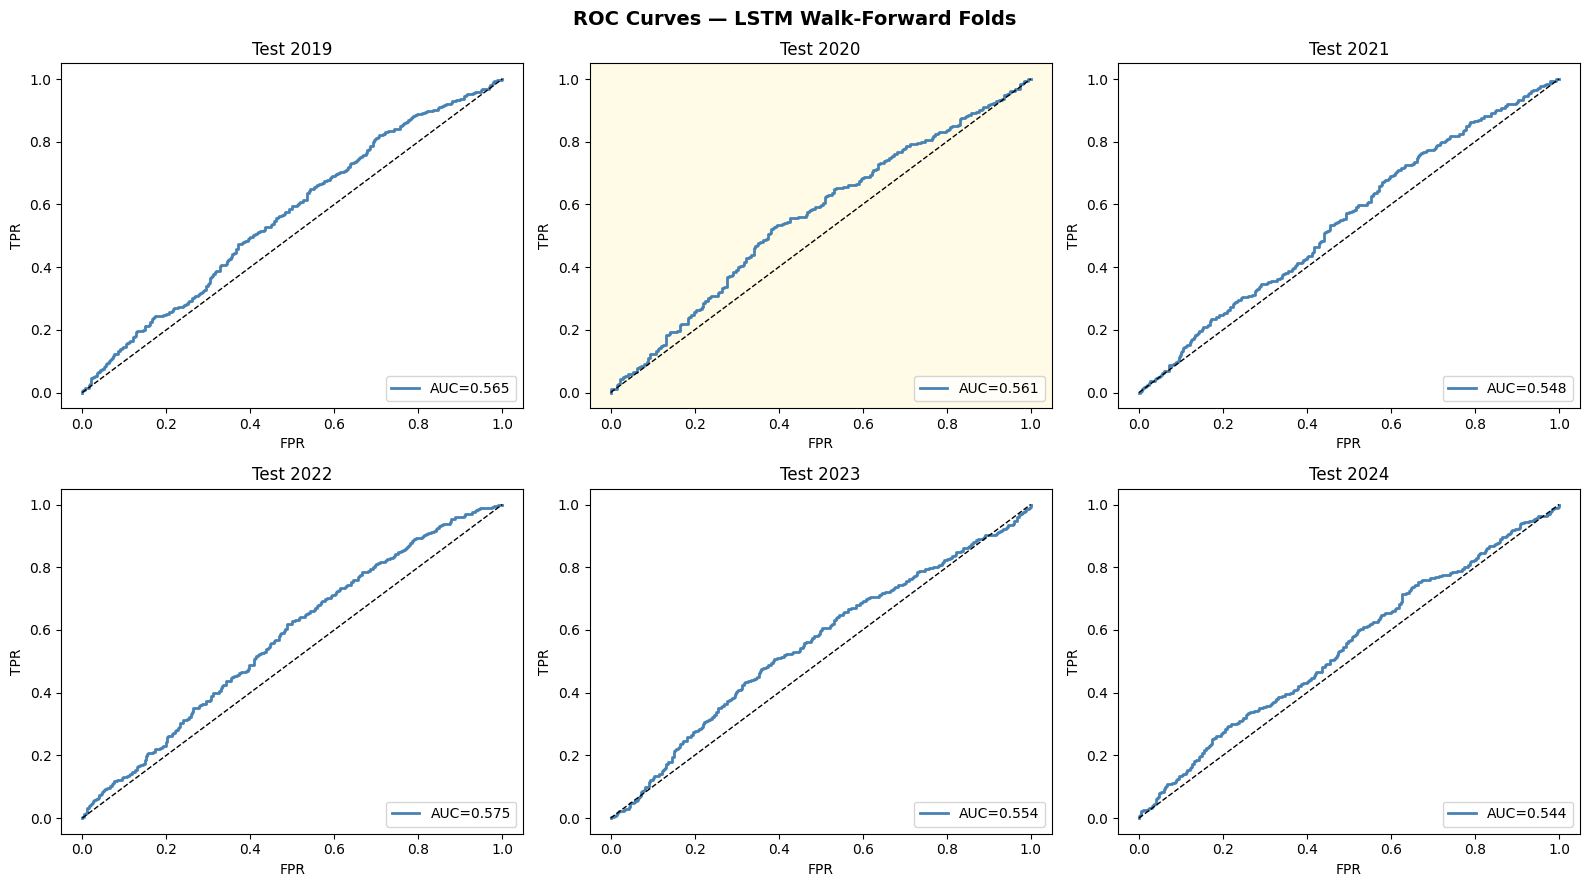

In [11]:
# ROC curves per fold.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (proba, y_test, row) in enumerate(zip(fold_proba, fold_y_test,
                                              fold_results)):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val      = row['AUC-ROC']
    ax = axes[i]
    ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={auc_val:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'Test {row["Test year"]}', fontsize=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right')
    if row['Test year'] == 2020:
        ax.set_facecolor('#fffbe6')

fig.suptitle('ROC Curves — LSTM Walk-Forward Folds', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

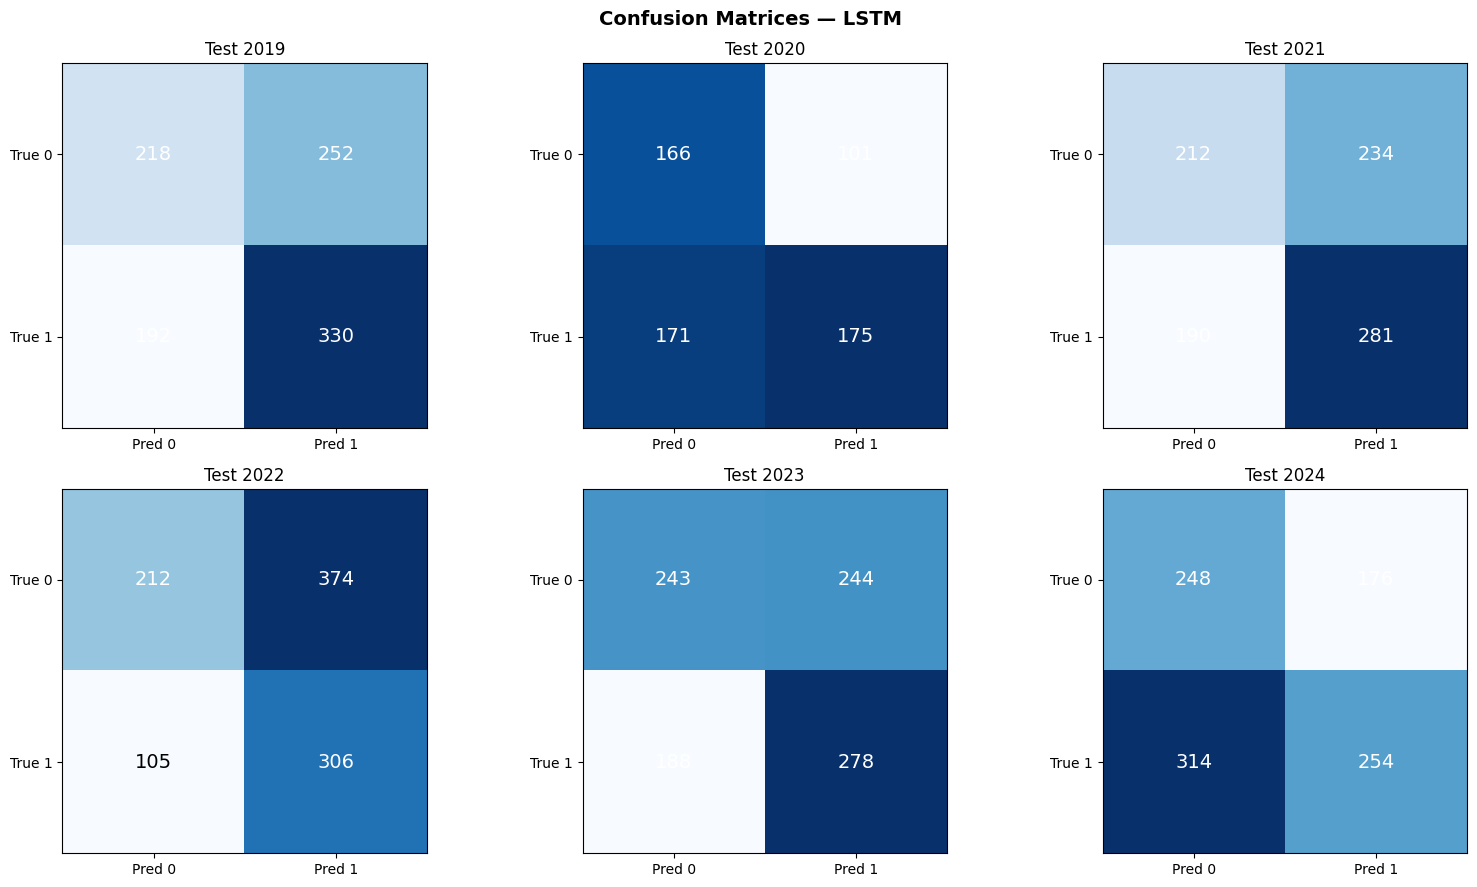

In [12]:
# Confusion matrices per fold.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (proba, y_test, row) in enumerate(zip(fold_proba, fold_y_test, fold_results)):
    preds = (proba >= 0.5).astype(int)
    cm    = confusion_matrix(y_test, preds)
    ax    = axes[i]
    im    = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center', fontsize=14,
                    color='white' if cm[r, c] > cm.max() / 2 else 'black')
    ax.set_title(f'Test {row["Test year"]}', fontsize=12)

fig.suptitle('Confusion Matrices — LSTM', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Permutation Feature Importance

For each feature, all values at that feature index are randomly shuffled across sequences (breaking the relationship between that feature and the target), and the AUC drop is measured. Averaged over 5 shuffles per feature per fold.

- **Positive drop:** shuffling hurts the model — the feature carries real signal in the temporal sequence
- **Near zero / negative:** the feature does not contribute to LSTM's predictions

This is more informative than LSTM weight magnitudes, which do not directly indicate feature contribution.

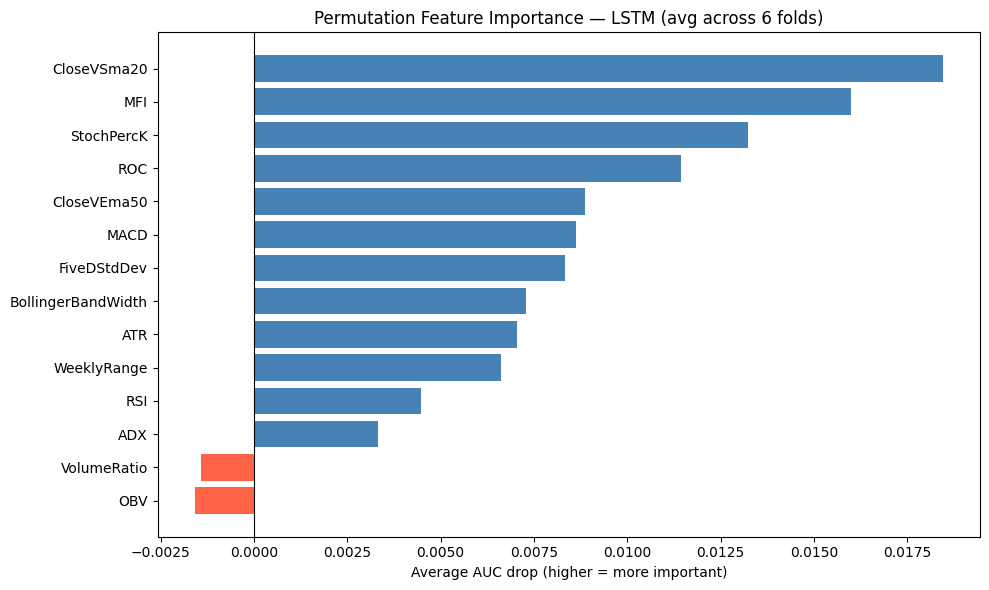

Feature importance (avg AUC drop when shuffled):
CloseVSma20           0.01844
MFI                   0.01600
StochPercK            0.01324
ROC                   0.01144
CloseVEma50           0.00886
MACD                  0.00861
FiveDStdDev           0.00833
BollingerBandWidth    0.00728
ATR                   0.00704
WeeklyRange           0.00661
RSI                   0.00446
ADX                   0.00333
VolumeRatio          -0.00142
OBV                  -0.00158


In [13]:
# Average permutation importance across all 6 folds.

imp_df = pd.DataFrame(fold_importances).T
imp_df.columns = [f['test_year'] for f in FOLDS]
imp_df['Avg AUC drop'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('Avg AUC drop', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v >= 0 else 'tomato' for v in imp_df['Avg AUC drop']]
ax.barh(imp_df.index, imp_df['Avg AUC drop'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Average AUC drop (higher = more important)')
ax.set_title('Permutation Feature Importance — LSTM (avg across 6 folds)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print('Feature importance (avg AUC drop when shuffled):')
print(imp_df['Avg AUC drop'].round(5).to_string())

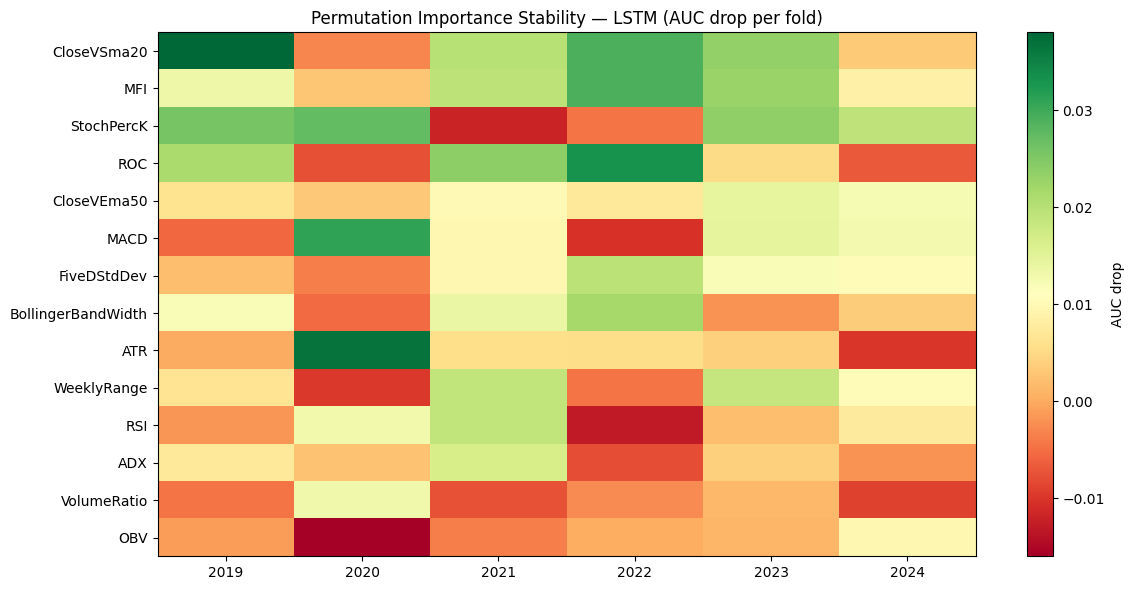

In [14]:
# Stability heatmap: importance per fold.
# Features that are consistently important across folds are robust signals.
# Features with high variance across folds may be fold-specific noise.

heatmap_data = imp_df.drop(columns='Avg AUC drop').astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
plt.colorbar(im, ax=ax, label='AUC drop')
ax.set_title('Permutation Importance Stability — LSTM (AUC drop per fold)')
plt.tight_layout(); plt.show()

In [15]:
# Cross-model feature importance comparison.
# LSTM: permutation importance (AUC drop rank).
# XGBoost: gain importance rank. LogReg: |coefficient| rank.
# Features ranked highly across all three models are robustly important.

lstm_rank = imp_df['Avg AUC drop'].rank(ascending=False).rename('LSTM rank')

xgb_rank_vals = {
    'StochPercK': 1, 'RSI': 2, 'ROC': 3, 'MACD': 4, 'MFI': 5,
    'FiveDStdDev': 6, 'VolumeRatio': 7, 'CloseVSma20': 8, 'RevGrowthQoQ': 9,
    'BollingerBandWidth': 10, 'OBV': 11, 'ADX': 12, 'CloseVEma50': 13,
    'ATR': 14, 'WeeklyRange': 15
}
logreg_rank_vals = {
    'StochPercK': 1, 'MFI': 2, 'MACD': 3, 'BollingerBandWidth': 4,
    'ROC': 5, 'VolumeRatio': 6, 'OBV': 7, 'NetMargin': 8,
    'ATR': 9, 'ADX': 10, 'CloseVEma50': 11,
    'FiveDStdDev': 11, 'CloseVSma20': 12, 'WeeklyRange': None, 'RSI': None
}

comparison = pd.DataFrame({'LSTM rank': lstm_rank})
comparison['XGBoost rank'] = comparison.index.map(xgb_rank_vals)
comparison['LogReg rank']  = comparison.index.map(logreg_rank_vals)
comparison = comparison.sort_values('LSTM rank')

print('Feature ranking comparison — LSTM vs XGBoost vs LogReg:')
print('(lower = more important, None = not in that model)')
print(comparison.to_string())

Feature ranking comparison — LSTM vs XGBoost vs LogReg:
(lower = more important, None = not in that model)
                    LSTM rank  XGBoost rank  LogReg rank
CloseVSma20               1.0             8         12.0
MFI                       2.0             5          2.0
StochPercK                3.0             1          1.0
ROC                       4.0             3          5.0
CloseVEma50               5.0            13         11.0
MACD                      6.0             4          3.0
FiveDStdDev               7.0             6         11.0
BollingerBandWidth        8.0            10          4.0
ATR                       9.0            14          9.0
WeeklyRange              10.0            15          NaN
RSI                      11.0             2          NaN
ADX                      12.0            12         10.0
VolumeRatio              13.0             7          6.0
OBV                      14.0            11          7.0


## 8. Hyperparameter Analysis

In [16]:
# Best hyperparameters per fold.
# Consistent selection across folds suggests a stable optimal configuration.
# High variance suggests the problem structure changes year to year.

params_df = pd.DataFrame(fold_best_params,
                         index=[f['test_year'] for f in FOLDS])
params_df.index.name = 'Test year'
print('Best hyperparameters per fold:')
print(params_df.to_string())
print()
print('Most common values selected:')
for col in params_df.columns:
    mode_val = params_df[col].mode()[0]
    pct      = (params_df[col] == mode_val).mean() * 100
    print(f'  {col:15s}: {mode_val}  ({pct:.0f}% of folds)')

Best hyperparameters per fold:
           hidden_size  dropout
Test year                      
2019                32      0.2
2020                64      0.2
2021                64      0.3
2022                32      0.2
2023                32      0.3
2024                64      0.2

Most common values selected:
  hidden_size    : 32  (50% of folds)
  dropout        : 0.2  (67% of folds)


## 9. Head-to-Head Comparison — All Three Models

In [17]:
# Direct metric comparison per fold and on average.
# AUC is the primary metric — immune to class imbalance and threshold choice.

logreg_per_fold = {
    2019: 0.5500, 2021: 0.5760, 2022: 0.5827, 2023: 0.5644, 2024: 0.5849
}
xgb_per_fold = {
    2019: 0.5500, 2021: 0.5340, 2022: 0.5930, 2023: 0.5690, 2024: 0.5860
}

rows = []
for row in fold_results:
    yr = row['Test year']
    if yr == 2020:
        continue
    rows.append({
        'Test year':      yr,
        'LSTM AUC':       row['AUC-ROC'],
        'XGBoost AUC':    xgb_per_fold.get(yr, float('nan')),
        'LogReg AUC':     logreg_per_fold.get(yr, float('nan')),
    })

cmp_df = pd.DataFrame(rows).set_index('Test year')
display(cmp_df.style.format('{:.4f}').highlight_max(axis=1, color='#d4edda'))

print()
lstm_avg   = cmp_df['LSTM AUC'].mean()
xgb_avg    = cmp_df['XGBoost AUC'].mean()
logreg_avg = cmp_df['LogReg AUC'].mean()
print(f'Average (non-COVID folds):')
print(f'  LSTM AUC:    {lstm_avg:.4f}')
print(f'  XGBoost AUC: {xgb_avg:.4f}   Delta vs LSTM: {lstm_avg - xgb_avg:+.4f}')
print(f'  LogReg AUC:  {logreg_avg:.4f}   Delta vs LSTM: {lstm_avg - logreg_avg:+.4f}')

,LSTM AUC,XGBoost AUC,LogReg AUC
Test year,,,
2019,0.5647,0.5500,0.5500
2021,0.5484,0.5340,0.5760
2022,0.5751,0.5930,0.5827
2023,0.5540,0.5690,0.5644
2024,0.5443,0.5860,0.5849



Average (non-COVID folds):
  LSTM AUC:    0.5573
  XGBoost AUC: 0.5664   Delta vs LSTM: -0.0091
  LogReg AUC:  0.5716   Delta vs LSTM: -0.0143


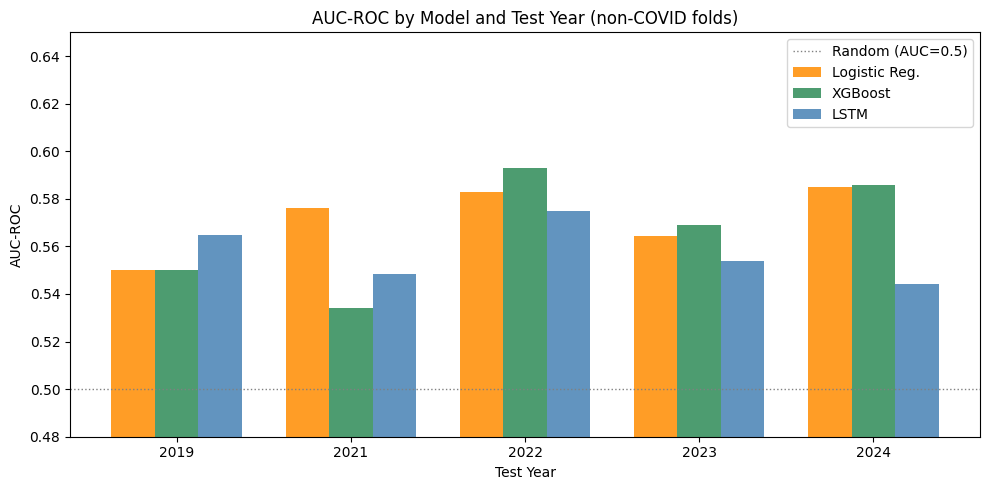

In [18]:
# Side-by-side AUC bar chart for the paper.

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(cmp_df))
width = 0.25

ax.bar(x - width, cmp_df['LogReg AUC'],   width, label='Logistic Reg.',  color='darkorange', alpha=0.85)
ax.bar(x,         cmp_df['XGBoost AUC'],  width, label='XGBoost',        color='seagreen',   alpha=0.85)
ax.bar(x + width, cmp_df['LSTM AUC'],     width, label='LSTM',           color='steelblue',  alpha=0.85)
ax.axhline(0.5, color='grey', ls=':', lw=1, label='Random (AUC=0.5)')

ax.set_xticks(x); ax.set_xticklabels(cmp_df.index)
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC by Model and Test Year (non-COVID folds)')
ax.legend(); ax.set_ylim(0.48, 0.65)
plt.tight_layout(); plt.show()

## 10. Secondary Evaluation — COVID Extreme Events

Same setup as LogReg and XGBoost secondary evaluations:
- Train on 2016–2019 (pre-COVID)
- Test on 291 COVID extreme event rows (Feb–May 2020)

For LSTM, sequences targeting COVID weeks draw their lookback from Dec 2019–Jan 2020 (all pre-COVID), so there is no data leakage. The COVID test sequences are built from `df_all` to include the extreme event rows as targets.

In [19]:
# Build sequences from the full dataset (primary + extreme) to get COVID target sequences.
# The extreme flag identifies which sequences have an extreme event as the target week.

X_full2, y_full2, years_full2, extreme_flags = build_sequences(
    df_all, FEATURES, TARGET, WINDOW)

# Pre-COVID training: non-extreme sequences from 2016-2019
mask_pre = (extreme_flags == 0) & (years_full2 < 2020)
X_pre_c, y_pre_c = X_full2[mask_pre], y_full2[mask_pre]

# COVID test: sequences whose target week is an extreme event
mask_cov = (extreme_flags == 1)
X_cov_c,  y_cov_c  = X_full2[mask_cov], y_full2[mask_cov]

# Inner val for early stopping: 2019 non-extreme sequences
mask_val_c = (extreme_flags == 0) & (years_full2 == 2019)
X_val_c, y_val_c = X_full2[mask_val_c], y_full2[mask_val_c]

# Scale: fit on pre-COVID training
n_feat = X_pre_c.shape[2]
scaler.fit(X_pre_c.reshape(-1, n_feat))

def sc2(X):
    return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape).astype(np.float32)

X_pre_s = sc2(X_pre_c)
X_val_s = sc2(X_val_c)
X_cov_s = sc2(X_cov_c)

# Use best params from fold 2 (which tested on 2020)
covid_params = fold_best_params[1]
torch.manual_seed(42)
covid_model, _ = fit_model(X_pre_s, y_pre_c, X_val_s, y_val_c, **covid_params)

cov_auc, cov_acc, cov_proba = evaluate(covid_model, X_cov_s, y_cov_c)
cov_preds    = (cov_proba >= 0.5).astype(int)
cov_baseline = max(y_cov_c.mean(), 1 - y_cov_c.mean())

print('Secondary evaluation — COVID extreme event rows (Feb-May 2020):')
print(f'  Metric          LSTM        XGBoost     LogReg')
print(f'  {"---":40s}')
print(f'  Accuracy         {cov_acc:.4f}      0.6392      —')
print(f'  Precision        {precision_score(y_cov_c, cov_preds, zero_division=0):.4f}      0.5625      —')
print(f'  Recall           {recall_score(y_cov_c, cov_preds, zero_division=0):.4f}      0.8931      —')
print(f'  F1               {f1_score(y_cov_c, cov_preds, zero_division=0):.4f}      0.6903      —')
print(f'  AUC-ROC          {cov_auc:.4f}      0.7243      0.7810')
print(f'  Baseline         {cov_baseline:.4f}      0.5498      —')
print()
print('Reminder: elevated COVID AUC across all models is an artifact of the')
print('crash being directionally unidirectional, not evidence of robustness.')

Secondary evaluation — COVID extreme event rows (Feb-May 2020):
  Metric          LSTM        XGBoost     LogReg
  ---                                     
  Accuracy         0.5464      0.6392      —
  Precision        0.4968      0.5625      —
  Recall           0.5954      0.8931      —
  F1               0.5417      0.6903      —
  AUC-ROC          0.5412      0.7243      0.7810
  Baseline         0.5498      0.5498      —

Reminder: elevated COVID AUC across all models is an artifact of the
crash being directionally unidirectional, not evidence of robustness.


## 11. Summary

In [20]:
lstm_avg_auc = non_covid['AUC-ROC'].mean()
lstm_avg_acc = non_covid['Accuracy'].mean()
lstm_avg_f1  = non_covid['F1'].mean()

mode_hidden = params_df['hidden_size'].mode()[0]
mode_drop   = params_df['dropout'].mode()[0]

top5 = imp_df['Avg AUC drop'].head(5)

print('=' * 65)
print('LSTM — RESULTS SUMMARY')
print('=' * 65)
print(f'Model:       LSTM (single layer, last-timestep output)')
print(f'Features:    {len(FEATURES)} technical (no fundamentals)')
print(f'Window:      {WINDOW} weeks')
print(f'Scaling:     StandardScaler (fit on training sequences only)')
print(f'Validation:  Expanding walk-forward, 6 folds (2019-2024)')
print()
print('Most common hyperparameters selected:')
print(f'  hidden_size : {mode_hidden}')
print(f'  dropout     : {mode_drop}')
print(f'  learning_rate: 0.001 (fixed)')
print()
print('Primary evaluation (excluding COVID fold):')
print(f'  Avg Accuracy:  {lstm_avg_acc:.4f}   (LogReg: 0.5523   XGBoost: 0.5542)')
print(f'  Avg F1:        {lstm_avg_f1:.4f}   (LogReg: 0.5668   XGBoost: 0.6163)')
print(f'  Avg AUC-ROC:   {lstm_avg_auc:.4f}   (LogReg: 0.5736   XGBoost: 0.5663)')
print(f'  Avg Baseline:  {non_covid["Baseline"].mean():.4f}')
print()
print('Top 5 features by permutation importance (avg AUC drop):')
for feat, drop in top5.items():
    print(f'  {feat:25s}  drop={drop:.5f}')
print()
print('COVID secondary AUC:')
print(f'  LSTM: {cov_auc:.4f}  |  XGBoost: 0.7243  |  LogReg: 0.7810')
print()
print('-' * 65)
print('MODEL COMPARISON (non-COVID, Avg AUC-ROC):')
print(f'  Majority class baseline : 0.500')
print(f'  XGBoost                 : 0.5663')
print(f'  LSTM                    : {lstm_avg_auc:.4f}')
print(f'  Logistic Regression     : 0.5736')
print('=' * 65)

LSTM — RESULTS SUMMARY
Model:       LSTM (single layer, last-timestep output)
Features:    14 technical (no fundamentals)
Window:      4 weeks
Scaling:     StandardScaler (fit on training sequences only)
Validation:  Expanding walk-forward, 6 folds (2019-2024)

Most common hyperparameters selected:
  hidden_size : 32
  dropout     : 0.2
  learning_rate: 0.001 (fixed)

Primary evaluation (excluding COVID fold):
  Avg Accuracy:  0.5325   (LogReg: 0.5523   XGBoost: 0.5542)
  Avg F1:        0.5601   (LogReg: 0.5668   XGBoost: 0.6163)
  Avg AUC-ROC:   0.5573   (LogReg: 0.5736   XGBoost: 0.5663)
  Avg Baseline:  0.5422

Top 5 features by permutation importance (avg AUC drop):
  CloseVSma20                drop=0.01844
  MFI                        drop=0.01600
  StochPercK                 drop=0.01324
  ROC                        drop=0.01144
  CloseVEma50                drop=0.00886

COVID secondary AUC:
  LSTM: 0.5412  |  XGBoost: 0.7243  |  LogReg: 0.7810

----------------------------------